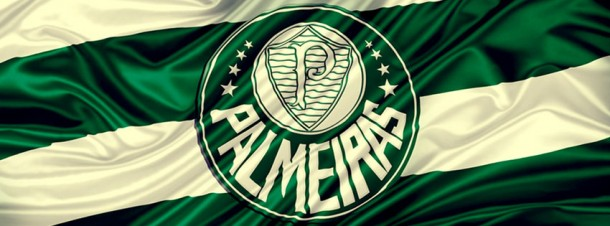

# Análise das Notícias do Palmeiras

Este notebook representa a etapa final do projeto 1 da disciplina **Perspectiva em Ciência de Dados**.

As etapas de **web scraping** e **Processamento de Linguagem Natural (PLN)** já foram feitas nos notebooks anteriores. Portanto, aqui o objetivo não é coletar os dados novamente nem refazer todo o tratamento textual do zero.

Neste notebook, vamos usar os arquivos gerados anteriormente para fazer:

- análise descritiva das notícias e das visitas;
- análise textual com palavras mais frequentes e nuvem de palavras;;
- visualização dos textos com t-SNE;
- modelo preditivo para identificar notícias com maior potencial de audiência.


## Site utilizado

As notícias foram coletadas do site: **https://www.verdaoweb.com.br/**

Para cada notícia foram coletadas as seguintes informações: **Título**, **Texto da notícia**, **Data** e **Número de visitas**.

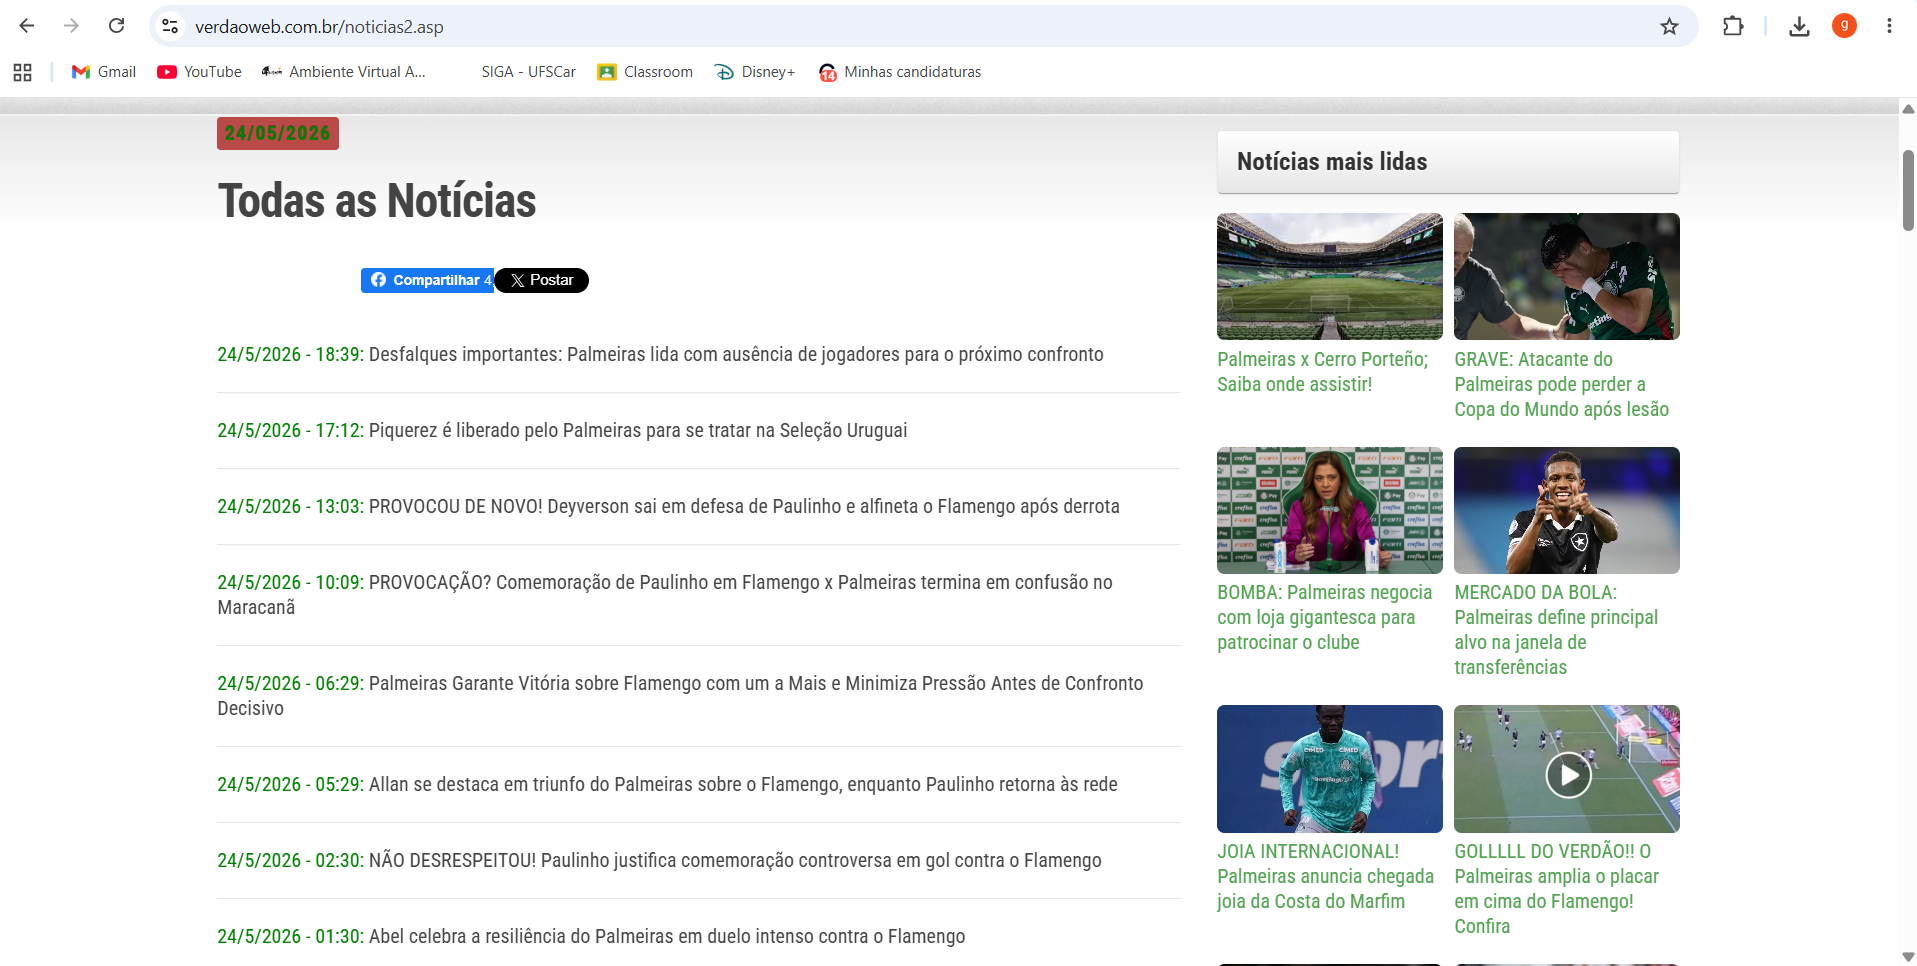

## Coleta das notícias por web scraping

A etapa de web scraping foi desenvolvida em aula e teve como objetivo coletar as notícias disponíveis no site.

De forma geral, cada página do site continha um bloco com várias notícias. Primeiro, foi feita a navegação página por página para identificar e armazenar os links de cada notícia.

Depois dessa primeira coleta de links, o processo entrou individualmente em cada notícia para extrair as informações necessárias para o projeto, como **título**, **texto da notícia**, **data de publicação** e **número de visitas**.


## Importação das bibliotecas

Nesta primeira parte, importamos as bibliotecas usadas na análise.

Usei o `pandas` para manipular os dados, o `matplotlib` para gráficos, o `wordcloud` para gerar a nuvem de palavras e o `scikit-learn` para a parte de machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from pathlib import Path
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

## Carregando os datasets gerados no PLN

Nos notebooks anteriores, foram gerados três arquivos principais:

- `noticias.csv`: contém os metadados, texto original e texto tratado;
- `bow.csv`: contém a representação Bag of Words;
- `tfidf.csv`: contém a representação TF-IDF.

Para esta análise, o dataset principal será o `noticias.csv`, porque ele é mais interpretável. Já o `bow.csv` e o `tfidf.csv` serão usados para as análises textuais e para os modelos.

In [3]:
from pathlib import Path
import pandas as pd

# A pasta "dados" está na raiz do repositório.
pasta_dados = Path("dados")

noticias = pd.read_csv(pasta_dados / "noticias.csv")
bow = pd.read_csv(pasta_dados / "bow.csv")
tfidf = pd.read_csv(pasta_dados / "tfidf.csv")

print(f"Notícias completas: {pasta_dados / 'noticias.csv'} - shape={noticias.shape}")
print(f"Bag of Words:       {pasta_dados / 'bow.csv'} - shape={bow.shape}")
print(f"TF-IDF:             {pasta_dados / 'tfidf.csv'} - shape={tfidf.shape}")

noticias.head()

Notícias completas: dados\noticias.csv - shape=(2000, 6)
Bag of Words:       dados\bow.csv - shape=(2000, 8444)
TF-IDF:             dados\tfidf.csv - shape=(2000, 8441)


,titulo,data,visitas,texto,texto_limpo,texto_sem_stopwords
0,STJD indefere pedido de suspensão e Abel Ferre...,11/4/2026 16:47,141,O Palmeiras terá uma nova rodada de desafios n...,o palmeiras tera uma nova rodada de desafios n...,palmeiras nova rodada desafios campeonato bras...
1,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,11/4/2026 16:47,129,O Nubank está explorando a possibilidade de or...,o nubank esta explorando a possibilidade de or...,nubank explorando possibilidade organizar amis...
2,STJD Recusa Suspensão de Abel Ferreira; Palmei...,11/4/2026 16:47,105,A Sociedade Esportiva Palmeiras manifestou sua...,a sociedade esportiva palmeiras manifestou sua...,sociedade esportiva palmeiras manifestou insat...
3,Palmeiras encerra treinos para o Dérbi com Vit...,11/4/2026 14:27,276,"Na manhã deste sábado (11), a Academia de Fute...",na manha deste sabado 11 a academia de futebol...,manha deste sabado 11 academia futebol palco u...
4,Messi Pode Anunciar Amistoso Histórico em São ...,11/4/2026 14:07,246,"A co-fundadora do Nubank, Cristina Junqueira, ...",a co fundadora do nubank cristina junqueira re...,co fundadora nubank cristina junqueira revelou...


In [4]:
bow.head()

,data,titulo,visitas,bow_abafa,bow_abaixo,bow_abalou,bow_abandonar,bow_abdicar,bow_abel,bow_aberta,bow_abertamente,bow_abertas,bow_aberto,bow_abertura,bow_abismo,bow_aborda,bow_abordada,bow_abordado,bow_abordagem,bow_abordagens,bow_abordando,bow_abordar,bow_abordou,bow_abrange,bow_abrangem,bow_abrangendo,bow_abrangente,bow_abre,bow_abril,bow_abrindo,bow_abrir,bow_abrira,bow_abriu,bow_absoluta,bow_absoluto,bow_absolutos,bow_absorcao,bow_abu,bow_acabaram,bow_acabou,bow_academia,bow_acalmar,bow_acalorada,bow_acaloradas,bow_acao,bow_acaso,bow_aceita,bow_aceitacao,bow_aceitam,bow_aceitar,...,bow_voltas,bow_volte,bow_voltem,bow_voltou,bow_volume,bow_vontade,bow_voo,bow_voos,bow_votacao,bow_votar,bow_voto,bow_votos,bow_vou,bow_voz,bow_vozes,bow_vs,bow_vulnerabilidade,bow_vulneravel,bow_walter,bow_wanderers,bow_washington,bow_web,bow_wembley,bow_wendel,bow_west,bow_weverton,bow_willian,bow_wolverhampton,bow_wtorre,bow_xadrez,bow_xeque,bow_xerife,bow_xg,bow_xxi,bow_yimmi,bow_youtube,bow_zaga,bow_zagueiro,bow_zagueiros,bow_zambia,bow_zaneratto,bow_zanni,bow_zanotti,bow_ze,bow_zenit,bow_zerar,bow_zero,bow_zona,bow_zorzi,bow_zubeldia
0,11/4/2026 16:47,STJD indefere pedido de suspensão e Abel Ferre...,141,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,11/4/2026 16:47,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,129,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,11/4/2026 16:47,STJD Recusa Suspensão de Abel Ferreira; Palmei...,105,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,11/4/2026 14:27,Palmeiras encerra treinos para o Dérbi com Vit...,276,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,11/4/2026 14:07,Messi Pode Anunciar Amistoso Histórico em São ...,246,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
tfidf.head()

,abafa,abaixo,abalou,abandonar,abdicar,abel,aberta,abertamente,abertas,aberto,abertura,abismo,aborda,abordada,abordado,abordagem,abordagens,abordando,abordar,abordou,abrange,abrangem,abrangendo,abrangente,abre,abril,abrindo,abrir,abrira,abriu,absoluta,absoluto,absolutos,absorcao,abu,acabaram,acabou,academia,acalmar,acalorada,acaloradas,acao,acaso,aceita,aceitacao,aceitam,aceitar,aceitavel,aceite,aceito,...,voltas,volte,voltem,voltou,volume,vontade,voo,voos,votacao,votar,voto,votos,vou,voz,vozes,vs,vulnerabilidade,vulneravel,walter,wanderers,washington,web,wembley,wendel,west,weverton,willian,wolverhampton,wtorre,xadrez,xeque,xerife,xg,xxi,yimmi,youtube,zaga,zagueiro,zagueiros,zambia,zaneratto,zanni,zanotti,ze,zenit,zerar,zero,zona,zorzi,zubeldia
0,0.0,0.0,0.0,0.0,0.0,0.075833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.070553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.098123,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.068345,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.042288,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.070858,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.062112,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.065333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Preparação da base para análise

Aqui fazemos alguns ajustes simples para garantir que a base esteja pronta para análise.

A coluna `data` será convertida para formato de data e a coluna `visitas` será convertida para número. Também criaremos algumas variáveis auxiliares, como dia da semana, mês.



In [6]:
df = noticias.copy()

# Convertendo visitas para número
df["visitas"] = (
    df["visitas"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)
df["visitas"] = pd.to_numeric(df["visitas"], errors="coerce")

# Convertendo data
df["data_original"] = df["data"]
df["data"] = pd.to_datetime(df["data"], dayfirst=True, errors="coerce")

# Variáveis de data
if "data" in df.columns:
    df["ano"] = df["data"].dt.year
    df["mes"] = df["data"].dt.month
    df["dia"] = df["data"].dt.day
    df["dia_semana"] = df["data"].dt.dayofweek  # segunda=0, domingo=6
    df["nome_dia_semana"] = df["data"].dt.day_name()
    df["hora"] = df["data"].dt.hour

# Variáveis de tamanho do texto
if "titulo" in df.columns:
    df["qtd_palavras_titulo"] = df["titulo"].str.split().str.len()

if "texto" in df.columns:
    df["qtd_palavras_texto"] = df["texto"].str.split().str.len()

# Removendo linhas sem visitas
df = df.dropna(subset=["visitas"]).reset_index(drop=True)

print(df.shape)
df.head()

(2000, 15)


,titulo,data,visitas,texto,texto_limpo,texto_sem_stopwords,data_original,ano,mes,dia,dia_semana,nome_dia_semana,hora,qtd_palavras_titulo,qtd_palavras_texto
0,STJD indefere pedido de suspensão e Abel Ferre...,2026-04-11 16:47:00,141,O Palmeiras terá uma nova rodada de desafios n...,o palmeiras tera uma nova rodada de desafios n...,palmeiras nova rodada desafios campeonato bras...,11/4/2026 16:47,2026,4,11,5,Saturday,16,16,319.0
1,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,2026-04-11 16:47:00,129,O Nubank está explorando a possibilidade de or...,o nubank esta explorando a possibilidade de or...,nubank explorando possibilidade organizar amis...,11/4/2026 16:47,2026,4,11,5,Saturday,16,13,265.0
2,STJD Recusa Suspensão de Abel Ferreira; Palmei...,2026-04-11 16:47:00,105,A Sociedade Esportiva Palmeiras manifestou sua...,a sociedade esportiva palmeiras manifestou sua...,sociedade esportiva palmeiras manifestou insat...,11/4/2026 16:47,2026,4,11,5,Saturday,16,11,338.0
3,Palmeiras encerra treinos para o Dérbi com Vit...,2026-04-11 14:27:00,276,"Na manhã deste sábado (11), a Academia de Fute...",na manha deste sabado 11 a academia de futebol...,manha deste sabado 11 academia futebol palco u...,11/4/2026 14:27,2026,4,11,5,Saturday,14,12,387.0
4,Messi Pode Anunciar Amistoso Histórico em São ...,2026-04-11 14:07:00,246,"A co-fundadora do Nubank, Cristina Junqueira, ...",a co fundadora do nubank cristina junqueira re...,co fundadora nubank cristina junqueira revelou...,11/4/2026 14:07,2026,4,11,5,Saturday,14,10,374.0


## Visão geral da base

Antes de entrar nos modelos, é importante entender a base de forma simples.

Nesta etapa, vamos olhar a quantidade de notícias, o total de visitas, a média, a mediana e os valores mais altos. Isso ajuda a ter uma noção geral do comportamento da audiência.

In [7]:
resumo_visitas = pd.DataFrame({
    "indicador": [
        "Quantidade de notícias",
        "Total de visitas",
        "Média de visitas",
        "Mediana de visitas",
        "Menor valor de visitas",
        "Maior valor de visitas"
    ],
    "valor": [
        len(df),
        df["visitas"].sum(),
        df["visitas"].mean(),
        df["visitas"].median(),
        df["visitas"].min(),
        df["visitas"].max()
    ]
})

resumo_visitas

,indicador,valor
0,Quantidade de notícias,2000.000
1,Total de visitas,3359430.000
2,Média de visitas,1679.715
3,Mediana de visitas,978.000
4,Menor valor de visitas,105.000
5,Maior valor de visitas,85839.000


## Notícias mais acessadas

Nesta parte, listamos as notícias com maior número de visitas.

Esse ranking ajuda a entender quais assuntos chamaram mais atenção do público.

In [8]:
top_noticias = df.sort_values("visitas", ascending=False)[[
    "titulo", "data", "visitas"
]].head(10)

top_noticias

,titulo,data,visitas
1673,Mais reforços a caminho? Palmeiras aproveita f...,2026-02-10 17:02:00,85839
1651,REFORÇO DE PESO! Palmeiras acerta a contrataçã...,2026-02-11 07:42:00,68550
914,PREMIAÇÃO ASTRONÔMICA: Confira quanto o Palmei...,2026-03-09 08:24:00,29481
1477,Palmeiras recebe proposta astronômica por Vito...,2026-02-19 08:21:00,27657
1367,Venda milionária? Palmeiras recebe propostas p...,2026-02-23 16:26:00,23760
743,Palmeiras negocia pacote do Zenit com Wendel e...,2026-03-15 14:53:00,21999
165,Palmeiras posta vídeo fazendo provocação a Rog...,2026-04-06 13:27:00,21939
1038,Presidente dos Estados Unidos exalta o Palmeir...,2026-03-06 10:23:00,20889
1567,Palmeiras e Guarani se enfrentam na 8ª rodada ...,2026-02-14 07:22:00,20688
227,Bahia x Palmeiras; Saiba onde assistir,2026-04-04 16:06:00,19209


## Quantidade de notícias e visitas por mês

Como a base possui a data de publicação das notícias, podemos analisar como a coleta e a audiência se distribuem ao longo do tempo.


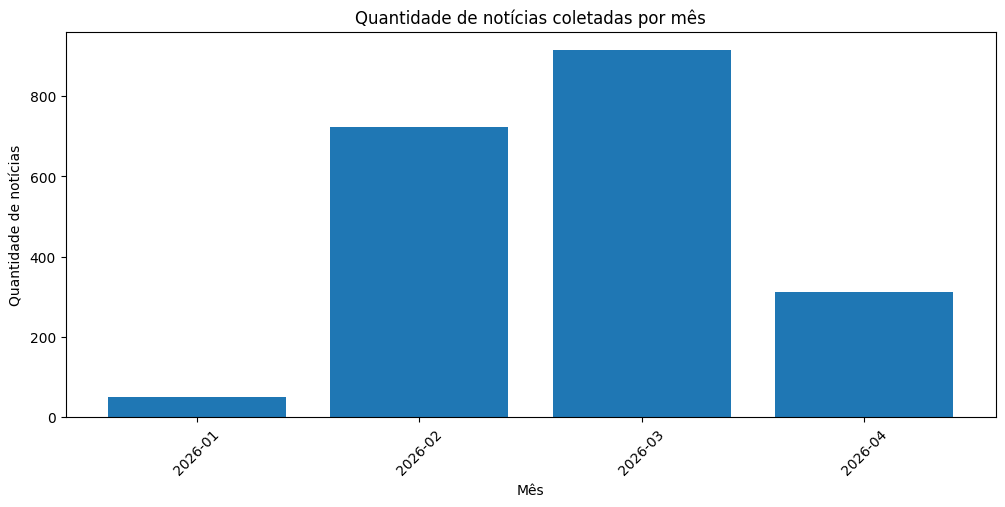

,periodo,qtd_noticias,total_visitas,media_visitas,mediana_visitas
0,2026-01,51,88425,1733.82,1038.0
1,2026-02,724,1495683,2065.86,1194.0
2,2026-03,914,1423146,1557.05,913.5
3,2026-04,311,352176,1132.40,471.0


In [9]:
# Quantidade de notícias e visitas por mês
resumo_mes = (
    df.dropna(subset=["data"])
    .assign(periodo=lambda x: x["data"].dt.to_period("M").astype(str))
    .groupby("periodo", as_index=False)
    .agg(
        qtd_noticias=("titulo", "count"),
        total_visitas=("visitas", "sum"),
        media_visitas=("visitas", "mean"),
        mediana_visitas=("visitas", "median")
    )
)

# Arredondando médias para ficar mais apresentável
resumo_mes["media_visitas"] = resumo_mes["media_visitas"].round(2)
resumo_mes["mediana_visitas"] = resumo_mes["mediana_visitas"].round(2)

# Gráfico: quantidade de notícias por mês
plt.figure(figsize=(12, 5))
plt.bar(resumo_mes["periodo"], resumo_mes["qtd_noticias"])
plt.title("Quantidade de notícias coletadas por mês")
plt.xlabel("Mês")
plt.ylabel("Quantidade de notícias")
plt.xticks(rotation=45)
plt.show()

# Tabela final com notícias e visitas
resumo_mes

## Notícias e visitas por dia da semana


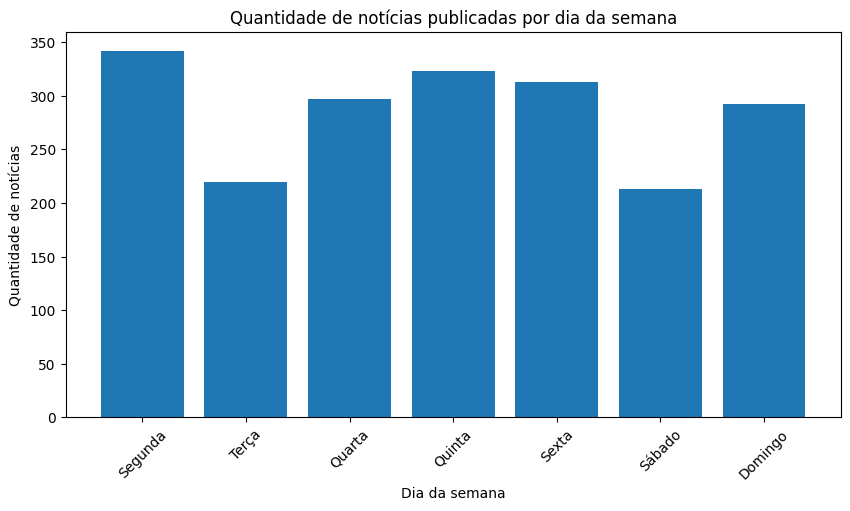

In [14]:
mapa_dias = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta",
    5: "Sábado",
    6: "Domingo"
}

# Quantidade de notícias publicadas por dia da semana
noticias_dia_semana = (
    df.dropna(subset=["dia_semana"])
      .groupby("dia_semana", as_index=False)
      .agg(qtd_noticias=("visitas", "size"))
)

# Nome dos dias
noticias_dia_semana["dia"] = noticias_dia_semana["dia_semana"].map(mapa_dias)

# Ordenando de segunda a domingo
noticias_dia_semana = noticias_dia_semana.sort_values("dia_semana")

# Gráfico
plt.figure(figsize=(10, 5))

plt.bar(
    noticias_dia_semana["dia"],
    noticias_dia_semana["qtd_noticias"]
)

plt.title("Quantidade de notícias publicadas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Quantidade de notícias")
plt.xticks(rotation=45)

plt.show()


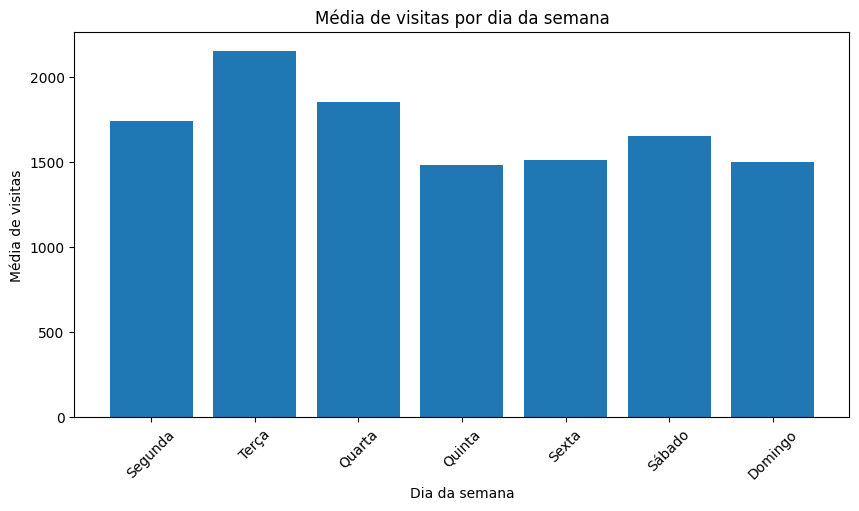

,dia,mean,median,count
0,Segunda,1741.078947,954.0,342
1,Terça,2151.681818,1252.5,220
2,Quarta,1851.646465,1125.0,297
3,Quinta,1481.015480,840.0,323
4,Sexta,1510.878594,786.0,313
5,Sábado,1651.492958,990.0,213
6,Domingo,1498.736301,906.0,292


In [10]:
mapa_dias = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta",
    5: "Sábado",
    6: "Domingo"
}

visitas_dia_semana = (
    df.dropna(subset=["dia_semana"])
    .groupby("dia_semana", as_index=False)["visitas"]
    .agg(["mean", "median", "count"])
    .reset_index()
)
visitas_dia_semana["dia"] = visitas_dia_semana["dia_semana"].map(mapa_dias)

plt.figure(figsize=(10, 5))
plt.bar(visitas_dia_semana["dia"], visitas_dia_semana["mean"])
plt.title("Média de visitas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Média de visitas")
plt.xticks(rotation=45)
plt.show()

visitas_dia_semana[["dia", "mean", "median", "count"]]

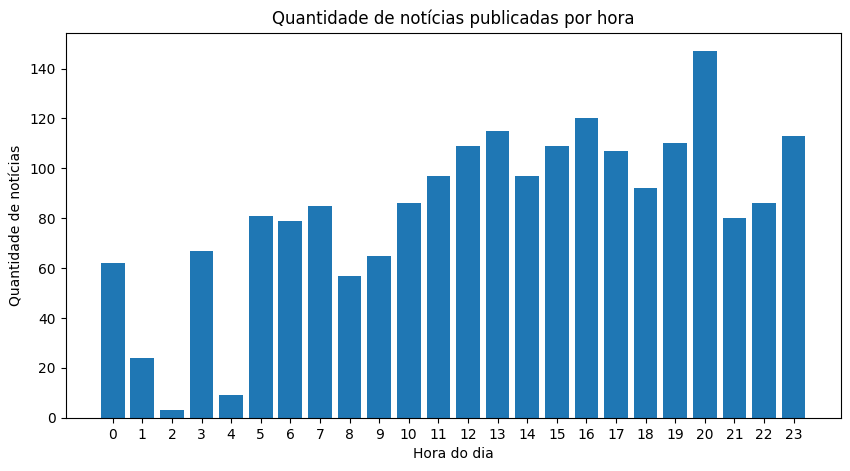

In [11]:
noticias_por_hora = (
    df.groupby("hora")
      .size()
      .reset_index(name="qtd_noticias")
      .sort_values("hora")
)

plt.figure(figsize=(10, 5))
plt.bar(noticias_por_hora["hora"], noticias_por_hora["qtd_noticias"])

plt.xlabel("Hora do dia")
plt.ylabel("Quantidade de notícias")
plt.title("Quantidade de notícias publicadas por hora")
plt.xticks(range(24))

plt.show()

# Análise textual com PLN

A partir daqui, vamos usar os textos já tratados no notebook de PLN.

O foco desta parte é entender quais palavras aparecem com mais frequência e se existem termos mais comuns em notícias de maior audiência.

## Nuvem de palavras

A nuvem de palavras mostra os termos mais frequentes nas notícias depois da remoção de stopwords.

Quanto maior a palavra aparece na imagem, maior foi sua frequência no conjunto de notícias.

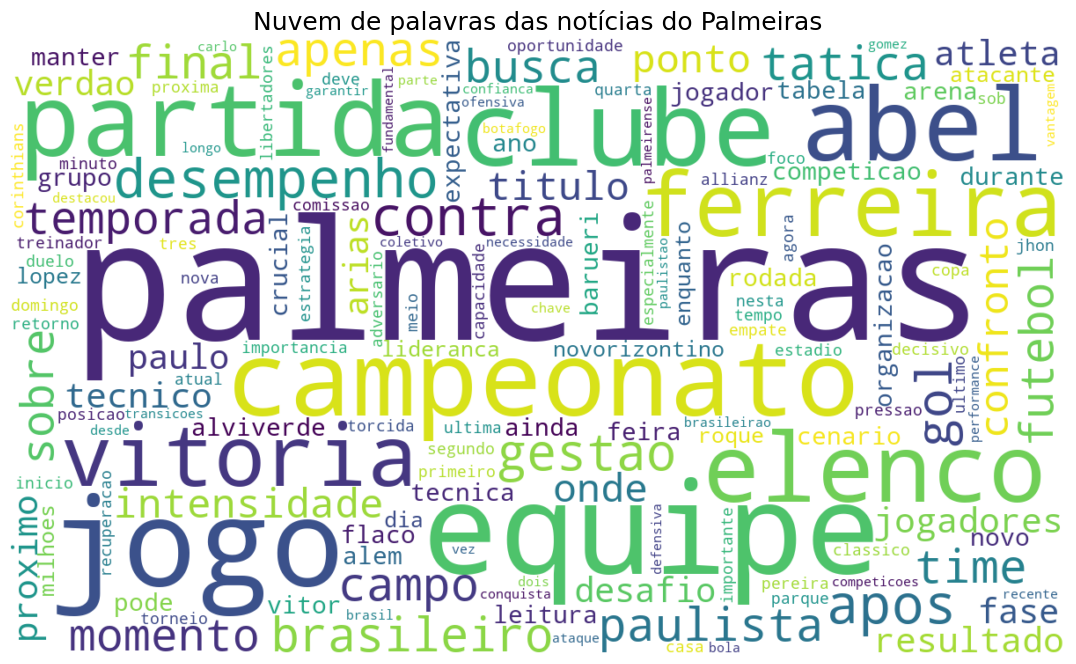

In [18]:
# Escolhendo a melhor coluna textual disponível
if "texto_sem_stopwords" in df.columns:
    coluna_texto_pln = "texto_sem_stopwords"
elif "texto_limpo" in df.columns:
    coluna_texto_pln = "texto_limpo"
else:
    coluna_texto_pln = "texto"

texto_geral = " ".join(df[coluna_texto_pln].fillna("").astype(str))

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    max_words=150,
    collocations=False
).generate(texto_geral)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras das notícias do Palmeiras", fontsize=18)
plt.show()

## Palavras mais frequentes

Além da nuvem de palavras, também é útil mostrar uma tabela com as palavras mais frequentes.

Aqui usamos a Bag of Words gerada no notebook de PLN. Ela transforma cada palavra em uma coluna e registra quantas vezes essa palavra apareceu.

,palavra,frequencia
0,palmeiras,8159
1,equipe,3782
2,jogo,2869
3,campeonato,2742
4,abel,2598
5,clube,2353
6,elenco,2283
7,ferreira,2203
8,apos,1964
9,desempenho,1947


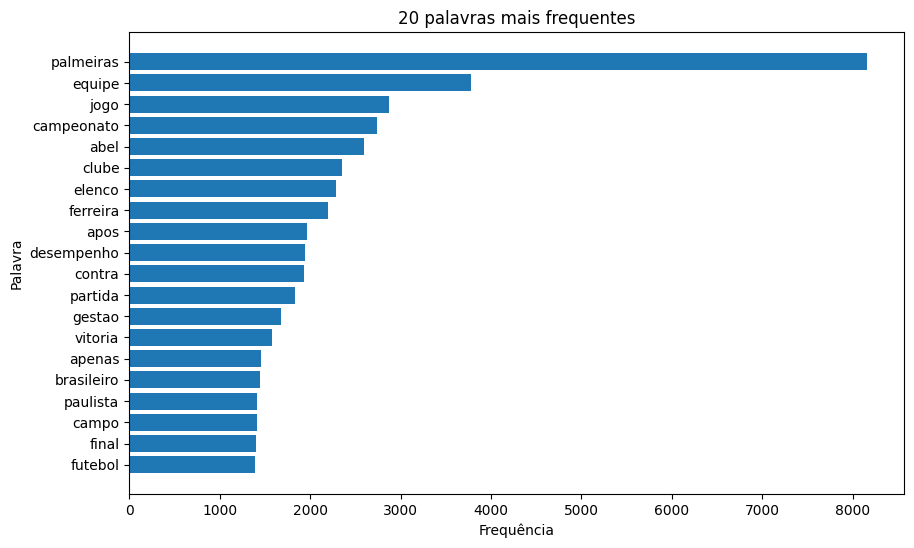

In [19]:
colunas_bow = [coluna for coluna in bow.columns if coluna.startswith("bow_")]
frequencia_palavras = bow[colunas_bow].sum().sort_values(ascending=False)
frequencia_palavras.index = frequencia_palavras.index.str.replace("bow_", "", regex=False)
    
top_palavras = frequencia_palavras.head(20).reset_index()
top_palavras.columns = ["palavra", "frequencia"]
display(top_palavras)
    
plt.figure(figsize=(10, 6))
plt.barh(top_palavras["palavra"][::-1], top_palavras["frequencia"][::-1])
plt.title("20 palavras mais frequentes")
plt.xlabel("Frequência")
plt.ylabel("Palavra")
plt.show()

## Notícias de alta audiência

Para facilitar a análise, vamos criar uma variável chamada `alta_audiencia`.

Neste notebook, uma notícia será considerada de alta audiência quando estiver entre as 30% notícias com mais visitas. Ou seja, usamos o percentil 70 como corte.

Isso permite transformar o problema em uma classificação simples:

- `1`: notícia de alta audiência;
- `0`: demais notícias.

Corte para alta audiência: 1479 visitas
alta_audiencia
0    1398
1     602
Name: count, dtype: int64


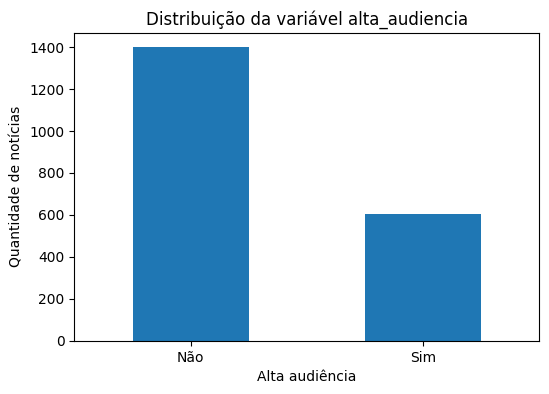

In [75]:
limite_alta_audiencia = df["visitas"].quantile(0.70)
df["alta_audiencia"] = (df["visitas"] >= limite_alta_audiencia).astype(int)

print(f"Corte para alta audiência: {limite_alta_audiencia:.0f} visitas")
print(df["alta_audiencia"].value_counts())

plt.figure(figsize=(6, 4))
df["alta_audiencia"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição da variável alta_audiencia")
plt.xlabel("Alta audiência")
plt.ylabel("Quantidade de notícias")
plt.xticks([0, 1], ["Não", "Sim"], rotation=0)
plt.show()

## Palavras mais comuns em notícias de alta audiência

Agora vamos comparar as palavras das notícias de alta audiência com as demais.

A ideia é identificar termos que aparecem com mais força nas notícias que tiveram mais visitas.

,palavra,freq_media_alta,freq_media_baixa,diferenca
0,mercado,0.369261,0.164109,0.205152
1,milhoes,0.506986,0.318212,0.188774
2,diretoria,0.329341,0.143429,0.185912
3,alviverde,0.542914,0.380921,0.161994
4,paulinho,0.335329,0.180120,0.155209
5,nino,0.195609,0.040694,0.154915
6,verdao,0.652695,0.498332,0.154362
7,janela,0.213573,0.061374,0.152199
8,brasileirao,0.371257,0.226818,0.144440
9,abel,1.397206,1.266177,0.131028


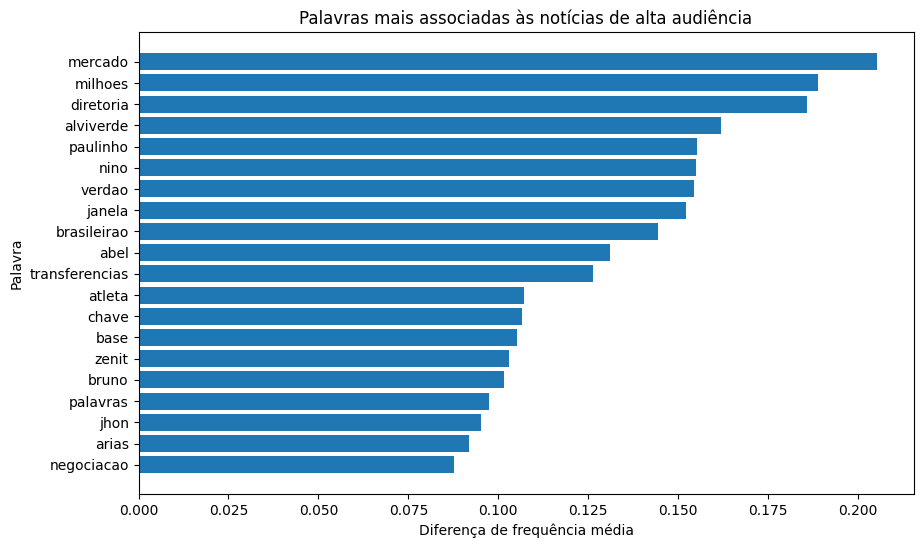

In [21]:
if bow is None:
    print("Arquivo bow.csv não encontrado. Esta análise precisa da Bag of Words gerada no notebook de PLN.")
else:
    # Garantindo que a ordem das linhas seja a mesma entre df e bow
    bow_temp = bow.copy().reset_index(drop=True)
    bow_temp["alta_audiencia"] = df["alta_audiencia"].values[:len(bow_temp)]
    
    colunas_bow = [coluna for coluna in bow_temp.columns if coluna.startswith("bow_")]
    
    freq_alta = bow_temp.loc[bow_temp["alta_audiencia"] == 1, colunas_bow].sum()
    freq_baixa = bow_temp.loc[bow_temp["alta_audiencia"] == 0, colunas_bow].sum()
    
    # Frequência média por grupo para não favorecer apenas o grupo com mais notícias
    freq_alta_media = freq_alta / max((bow_temp["alta_audiencia"] == 1).sum(), 1)
    freq_baixa_media = freq_baixa / max((bow_temp["alta_audiencia"] == 0).sum(), 1)
    
    comparacao_palavras = pd.DataFrame({
        "freq_media_alta": freq_alta_media,
        "freq_media_baixa": freq_baixa_media
    })
    comparacao_palavras["diferenca"] = comparacao_palavras["freq_media_alta"] - comparacao_palavras["freq_media_baixa"]
    comparacao_palavras.index = comparacao_palavras.index.str.replace("bow_", "", regex=False)
    
    palavras_alta = comparacao_palavras.sort_values("diferenca", ascending=False).head(20).reset_index()
    palavras_alta.columns = ["palavra", "freq_media_alta", "freq_media_baixa", "diferenca"]
    
    display(palavras_alta)
    
    plt.figure(figsize=(10, 6))
    plt.barh(palavras_alta["palavra"][::-1], palavras_alta["diferenca"][::-1])
    plt.title("Palavras mais associadas às notícias de alta audiência")
    plt.xlabel("Diferença de frequência média")
    plt.ylabel("Palavra")
    plt.show()

## Palavras mais relevantes por TF-IDF

A frequência simples mostra palavras que aparecem muitas vezes. Já o TF-IDF tenta destacar palavras mais relevantes, reduzindo o peso de termos que aparecem em praticamente todos os textos.

Aqui vamos observar os termos com maior soma de TF-IDF no conjunto de notícias.

,palavra,tfidf_total
0,palmeiras,145.268954
1,equipe,91.496395
2,campeonato,69.310295
3,jogo,67.067720
4,abel,66.636745
5,clube,60.952330
6,ferreira,57.192076
7,partida,55.270934
8,contra,53.621363
9,elenco,52.989813


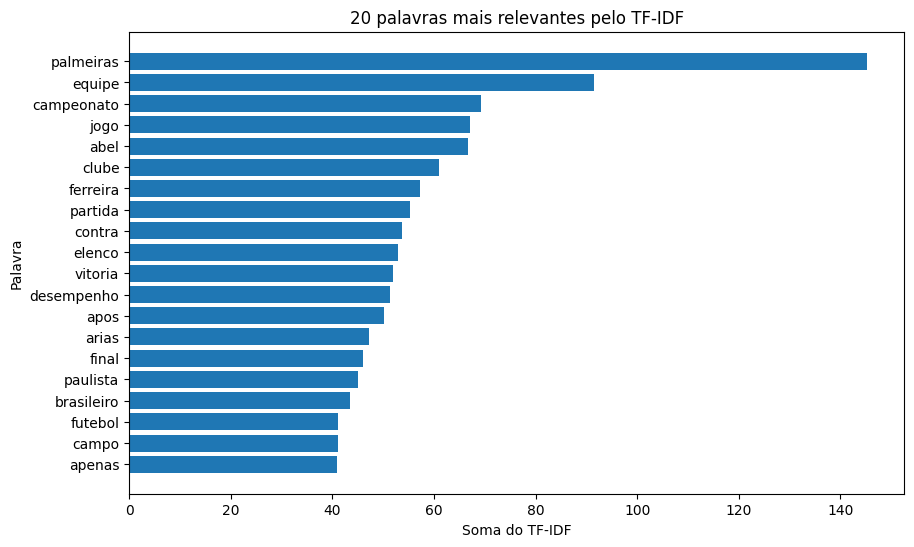

In [83]:
if tfidf is None:
    print("Arquivo tfidf.csv não encontrado. Esta análise precisa do TF-IDF gerado no notebook de PLN.")
else:
    # Caso o TF-IDF tenha vindo sem prefixo, usamos somente as colunas numéricas.
    colunas_tfidf = [c for c in tfidf.columns if c.startswith("tfidf_")]
    if len(colunas_tfidf) == 0:
        colunas_tfidf = tfidf.select_dtypes(include=[np.number]).columns.tolist()
    
    soma_tfidf = tfidf[colunas_tfidf].sum().sort_values(ascending=False)
    soma_tfidf.index = soma_tfidf.index.str.replace("tfidf_", "", regex=False)
    
    top_tfidf = soma_tfidf.head(20).reset_index()
    top_tfidf.columns = ["palavra", "tfidf_total"]
    display(top_tfidf)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_tfidf["palavra"][::-1], top_tfidf["tfidf_total"][::-1])
    plt.title("20 palavras mais relevantes pelo TF-IDF")
    plt.xlabel("Soma do TF-IDF")
    plt.ylabel("Palavra")
    plt.show()

## Visualização com t-SNE

O t-SNE reduz a representação TF-IDF para duas dimensões.

Cada ponto do gráfico representa uma notícia. Pontos próximos indicam textos parecidos. As cores representam os clusters criados pelo K-Means.

In [84]:
import pandas as pd
import plotly.express as px
from pathlib import Path
from sklearn.manifold import TSNE

# Pasta dados na raiz do repositório
pasta_dados = Path("dados")

df_bow = pd.read_csv(pasta_dados / "bow.csv")
df_tfidf = pd.read_csv(pasta_dados / "tfidf.csv")

# Colunas da Bag of Words
colunas_bow = [c for c in df_bow.columns if c.startswith("bow_")]

# Colunas numéricas do TF-IDF
colunas_tfidf = df_tfidf.select_dtypes(include="number").columns.tolist()

X_bow = df_bow[colunas_bow].values
X_tfidf = df_tfidf[colunas_tfidf].values

titulos = df_bow["titulo"].tolist()

perplexity = 5
random_state = 42

tsne_bow = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=random_state,
    init="random"
)

embed_bow = tsne_bow.fit_transform(X_bow)

tsne_tfidf = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=random_state,
    init="random"
)

embed_tfidf = tsne_tfidf.fit_transform(X_tfidf)

print("embed_bow:  ", embed_bow.shape)
print("embed_tfidf:", embed_tfidf.shape)

embed_bow:   (2000, 2)
embed_tfidf: (2000, 2)


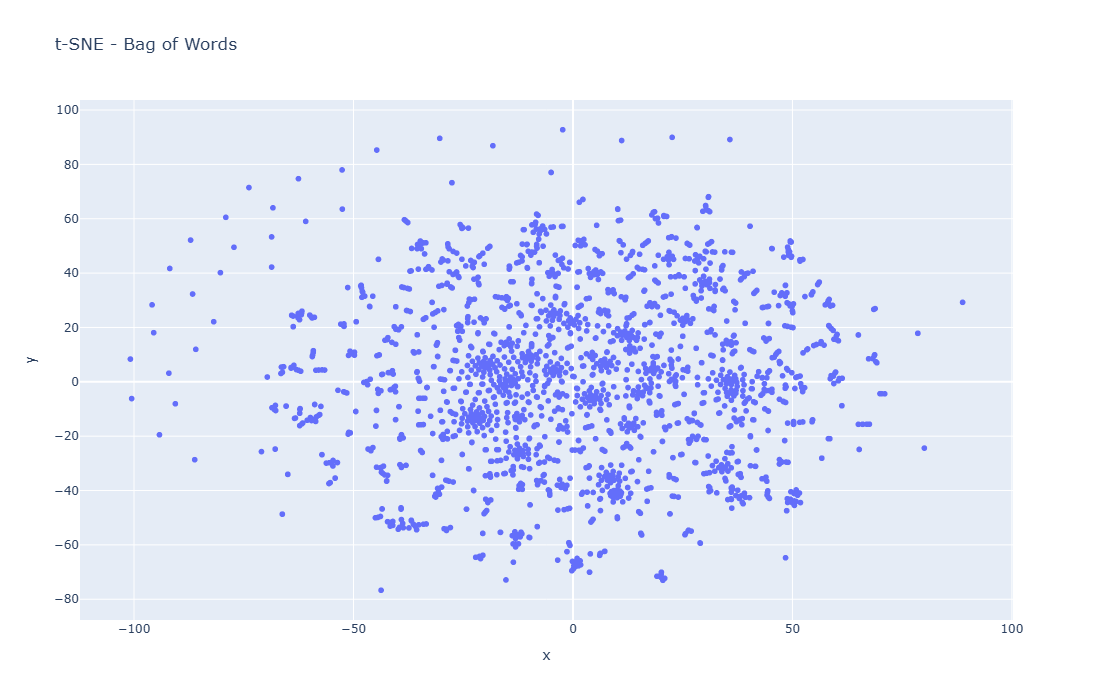

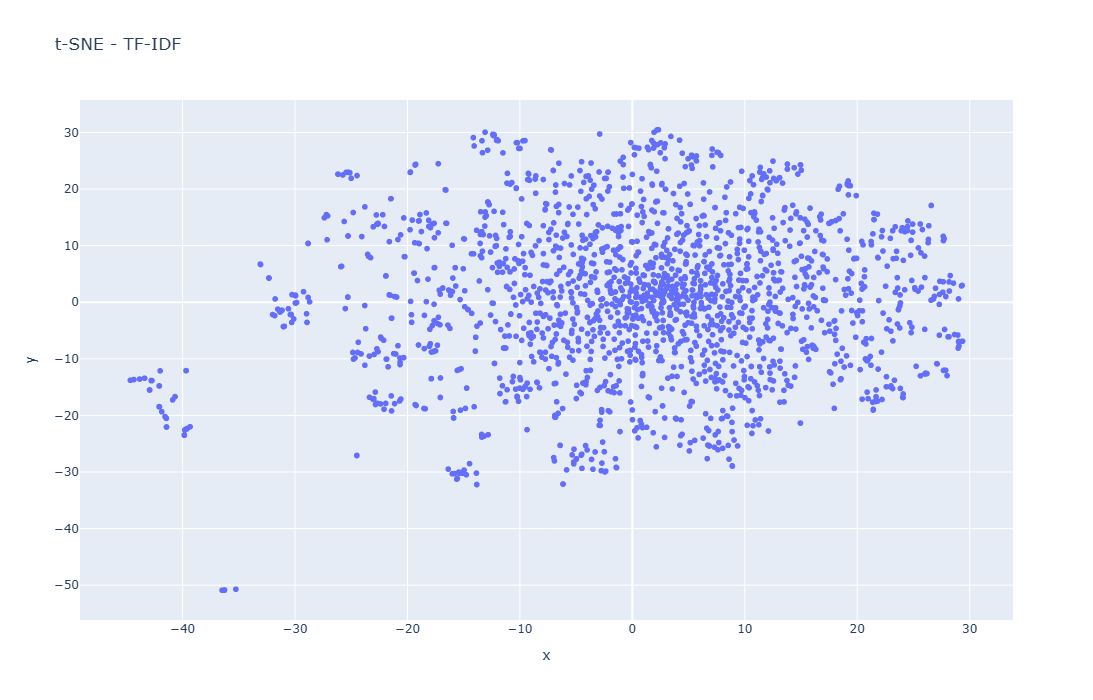

## Modelo preditivo

Depois da análise descritiva e da análise textual, foi construída uma etapa de aprendizado supervisionado.

A ideia aqui é usar as representações numéricas dos textos, principalmente o TF-IDF, para tentar prever características relacionadas à audiência das notícias.

Foram feitos dois modelos:

1. **Classificação:** prever se uma notícia pertence ao grupo de alta audiência.
2. **Regressão:** prever o número de visitas da notícia.

Para evitar avaliar o modelo nos mesmos dados usados no treinamento, a base foi separada em três partes: treino, calibração e teste.

- O conjunto de treino é usado para ajustar o modelo.
- O conjunto de calibração é usado para escolher limiares ou hiperparâmetros.
- O conjunto de teste é usado apenas no final, para avaliar o desempenho em dados que o modelo ainda não viu.

In [35]:
# Carregando os dados gerados no notebook de PLN
pasta_dados = Path("dados")

df_tfidf = pd.read_csv(pasta_dados / "tfidf.csv")
df_noticias = pd.read_csv(pasta_dados / "noticias.csv")

print("TF-IDF:", df_tfidf.shape)
print("Notícias:", df_noticias.shape)

df_tfidf.head()

TF-IDF: (2000, 8441)
Notícias: (2000, 6)


,abafa,abaixo,abalou,abandonar,abdicar,abel,aberta,abertamente,abertas,aberto,abertura,abismo,aborda,abordada,abordado,abordagem,abordagens,abordando,abordar,abordou,abrange,abrangem,abrangendo,abrangente,abre,abril,abrindo,abrir,abrira,abriu,absoluta,absoluto,absolutos,absorcao,abu,acabaram,acabou,academia,acalmar,acalorada,acaloradas,acao,acaso,aceita,aceitacao,aceitam,aceitar,aceitavel,aceite,aceito,...,voltas,volte,voltem,voltou,volume,vontade,voo,voos,votacao,votar,voto,votos,vou,voz,vozes,vs,vulnerabilidade,vulneravel,walter,wanderers,washington,web,wembley,wendel,west,weverton,willian,wolverhampton,wtorre,xadrez,xeque,xerife,xg,xxi,yimmi,youtube,zaga,zagueiro,zagueiros,zambia,zaneratto,zanni,zanotti,ze,zenit,zerar,zero,zona,zorzi,zubeldia
0,0.0,0.0,0.0,0.0,0.0,0.075833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.070553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.098123,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.068345,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.042288,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.070858,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.062112,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.065333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
# O TF-IDF será usado como matriz de entrada do modelo, pois transforma o texto das notícias
# em variáveis numéricas.
#
# Já a variável resposta do modelo vem do arquivo noticias.csv, porque é nele que está
# a informação de audiência, representada pela coluna "visitas".
#
# Portanto, a lógica desta etapa é:
# X = variáveis de texto geradas pelo TF-IDF
# y = audiência da notícia, medida pelo número de visitas

# Como os arquivos foram gerados a partir da mesma base, esperamos que eles tenham
# a mesma quantidade de linhas e estejam na mesma ordem.
# Essa checagem garante que cada linha do TF-IDF corresponde à mesma notícia
# no arquivo noticias.csv.
if len(df_noticias) != len(df_tfidf):
    raise ValueError("Os arquivos noticias.csv e tfidf.csv têm quantidades diferentes de linhas.")

# Selecionando apenas as colunas numéricas do TF-IDF.
# Essas colunas representam as palavras transformadas em variáveis numéricas.
colunas_tfidf = df_tfidf.select_dtypes(include="number").columns.tolist()

X = df_tfidf[colunas_tfidf].values

# Criando o alvo de classificação.
# Alta audiência = notícias que estão entre as 25% mais visitadas da base.
limite_alta_audiencia = df_noticias["visitas"].quantile(0.70)

y_clf = (df_noticias["visitas"] >= limite_alta_audiencia).astype(int).values

print("X:", X.shape)
print("y:", y_clf.shape)
print(f"Limite para alta audiência: {limite_alta_audiencia:.0f} visitas")
print("Distribuição das classes:")
print(pd.Series(y_clf).value_counts())

X: (2000, 8441)
y: (2000,)
Limite para alta audiência: 1479 visitas
Distribuição das classes:
0    1398
1     602
Name: count, dtype: int64


In [68]:
# Separando a base em treino e teste.
# O stratify=y mantém a proporção de notícias de alta e baixa audiência nos dois grupos.

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Treino:", X_treino.shape)
print("Teste: ", X_teste.shape)

Treino: (1400, 8441)
Teste:  (600, 8441)


In [69]:
# ============================================================
# Função para calcular métricas
# ============================================================

def calcular_metricas(y_real, y_pred):
    """
    Calcula métricas de classificação binária.

    Considerando:
    1 = alta audiência
    0 = não alta audiência

    Sensibilidade:
    capacidade do modelo identificar corretamente as notícias de alta audiência.

    Especificidade:
    capacidade do modelo identificar corretamente as notícias que não são de alta audiência.
    """
    
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    
    acuracia = accuracy_score(y_real, y_pred)
    sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0
    precisao = precision_score(y_real, y_pred, zero_division=0)
    f1 = f1_score(y_real, y_pred, zero_division=0)
    
    return {
        "Acurácia": acuracia,
        "Sensibilidade": sensibilidade,
        "Especificidade": especificidade,
        "Precisão": precisao,
        "F1-score": f1,
        "VP": tp,
        "VN": tn,
        "FP": fp,
        "FN": fn
    }

In [70]:
# ============================================================
# Modelo 1: Regressão Logística
# ============================================================

modelo_logistico = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo_logistico.fit(X_treino, y_treino)

pred_logistico = modelo_logistico.predict(X_teste)

metricas_logistico = calcular_metricas(y_teste, pred_logistico)

metricas_logistico

{'Acurácia': 0.71,
 'Sensibilidade': np.float64(0.5533333333333333),
 'Especificidade': np.float64(0.7622222222222222),
 'Precisão': 0.4368421052631579,
 'F1-score': 0.48823529411764705,
 'VP': np.int64(83),
 'VN': np.int64(343),
 'FP': np.int64(107),
 'FN': np.int64(67)}

In [71]:
# ============================================================
# Modelo 2: Árvore de Classificação
# ============================================================
from sklearn.tree import DecisionTreeClassifier, plot_tree
modelo_arvore = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

modelo_arvore.fit(X_treino, y_treino)

pred_arvore = modelo_arvore.predict(X_teste)

metricas_arvore = calcular_metricas(y_teste, pred_arvore)

metricas_arvore

{'Acurácia': 0.6416666666666667,
 'Sensibilidade': np.float64(0.5533333333333333),
 'Especificidade': np.float64(0.6711111111111111),
 'Precisão': 0.3593073593073593,
 'F1-score': 0.4356955380577428,
 'VP': np.int64(83),
 'VN': np.int64(302),
 'FP': np.int64(148),
 'FN': np.int64(67)}

In [72]:
# Comparando os modelos em uma tabela

comparacao_modelos = pd.DataFrame([
    {"Modelo": "Regressão Logística", **metricas_logistico},
    {"Modelo": "Árvore de Classificação", **metricas_arvore}
])

# Separando métricas principais das contagens da matriz de confusão
colunas_metricas = [
    "Modelo",
    "Acurácia",
    "Sensibilidade",
    "Especificidade",
    "Precisão",
    "F1-score"
]

comparacao_modelos[colunas_metricas].round(3)

,Modelo,Acurácia,Sensibilidade,Especificidade,Precisão,F1-score
0,Regressão Logística,0.710,0.553,0.762,0.437,0.488
1,Árvore de Classificação,0.642,0.553,0.671,0.359,0.436


In [73]:
# Matriz de confusão da Regressão Logística

cm_logistico = confusion_matrix(y_teste, pred_logistico)

matriz_logistico = pd.DataFrame(
    cm_logistico,
    index=["Real: não alta", "Real: alta"],
    columns=["Previsto: não alta", "Previsto: alta"]
)

matriz_logistico

,Previsto: não alta,Previsto: alta
Real: não alta,343,107
Real: alta,67,83


In [74]:
# Matriz de confusão da Árvore de Classificação

cm_arvore = confusion_matrix(y_teste, pred_arvore)

matriz_arvore = pd.DataFrame(
    cm_arvore,
    index=["Real: não alta", "Real: alta"],
    columns=["Previsto: não alta", "Previsto: alta"]
)

matriz_arvore

,Previsto: não alta,Previsto: alta
Real: não alta,302,148
Real: alta,67,83
